In [3]:
# WHAT: Prepare data for forecasting
# WHY: Machine learning needs structured time-series data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append(r'D:\Vaidehi Study\Regional_Sales_Analysis\04_scripts')
from config import DB_CONFIG, CSV_PATHS

engine = create_engine(f"mysql+pymysql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}")
df = pd.read_sql("SELECT * FROM v_master_sales_report", con=engine)

print("✅ Data loaded for forecasting")

✅ Data loaded for forecasting


In [4]:

# Converting daily sales to monthly totals
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['YearMonth'] = df['OrderDate'].dt.to_period('M')

monthly_revenue = df.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly_revenue.columns = ['Month_Period', 'Revenue']

# --- NEW: FEATURE ENGINEERING (THE FIX) ---
# 1. Add Month and Quarter as features for Seasonality
monthly_revenue['Month_Val'] = monthly_revenue['Month_Period'].dt.month
monthly_revenue['Quarter'] = monthly_revenue['Month_Period'].dt.quarter

# 2. Add Lag Feature (The most important predictor)
monthly_revenue['Prev_Month_Revenue'] = monthly_revenue['Revenue'].shift(1)

# 3. Add Numerical Time Index (Your original idea, kept as a trend feature)
monthly_revenue['TimeIndex'] = range(len(monthly_revenue))

# Drop the first row because it now has a 'NaN' for Prev_Month_Revenue
monthly_revenue.dropna(inplace=True)

print("PREPARED DATA WITH FEATURES:")
print(monthly_revenue.head())

PREPARED DATA WITH FEATURES:
  Month_Period    Revenue  Month_Val  Quarter  Prev_Month_Revenue  TimeIndex
1      2022-02  1256771.4          2        1           1305145.6          1
2      2022-03  1580290.4          3        1           1256771.4          2
3      2022-04  1197330.5          4        2           1580290.4          3
4      2022-05  1328354.5          5        2           1197330.5          4
5      2022-06  1377730.3          6        2           1328354.5          5


In [10]:
# 1. Define the Simplified Features- New Linear Regression Model
# We only care about the Month (Season) and the TimeIndex (Growth)
features_simple = ['Month_Val', 'TimeIndex']
X_simple = monthly_revenue[features_simple]
y_simple = monthly_revenue['Revenue']

# 2. Split (Keep the last 6 months for testing)
split = len(monthly_revenue) - 6
X_train_s, X_test_s = X_simple.iloc[:split], X_simple.iloc[split:]
y_train_s, y_test_s = y_simple.iloc[:split], y_simple.iloc[split:]

# 3. Build & Train
model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

# 4. Check the New Score
y_pred_s = model_simple.predict(X_test_s)
new_r2_simple = r2_score(y_test_s, y_pred_s)

print(f"--- SIMPLIFIED MODEL RESULTS ---")
print(f"New R² Score: {new_r2_simple:.4f}")
# print(f"Mean Absolute Error: ${mean_absolute_error(y_test_s, y_pred_s):.2f}")

--- SIMPLIFIED MODEL RESULTS ---
New R² Score: -0.3412


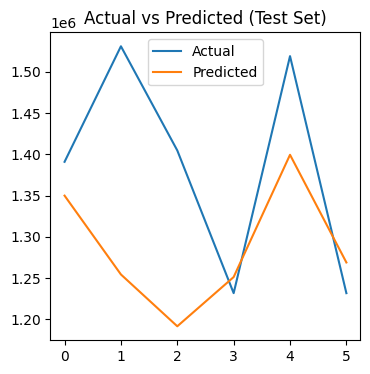

In [28]:
# Quick code to see where the model is lying to me since the R-square score is -0.3412.
# lines are going in opposite directions, My Features are contradicting each other.
# If the predicted line is way higher/lower: I have a trend shift.

plt.figure(figsize=(4,4), dpi=100)
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted (Test Set)")
plt.savefig(r'D:\Vaidehi Study\Regional_Sales_Analysis\05_results\Test_Set_Actual_Vs_Predicted.png', dpi=300, bbox_inches='tight')
plt.show()
# Conclusion: My model is directional (it knows when things should go up or down) 
# but lacks precision (it's missing the exact values by a margin of about to units in some places).